In [ ]:
#Data collection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("/content/drive/MyDrive/Copy of city_day (1).xlsx")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Data processing
df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64


In [ ]:
#Data understanding
print(df.shape)
print("\n",df.dtypes)
print("\n",df.describe())

(29531, 16)

 City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
dtype: object

                                 Date         PM2.5          PM10           NO  \
count                          29531  29531.000000  29531.000000  29531.00000   
mean   2018-05-14 05:40:15.807118080     67.450578    118.127103     17.57473   
min              2015-01-01 00:00:00      0.040000      0.010000      0.02000   
25%              2017-04-16 00:00:00     32.150000     79.315000      6.21000   
50%              2018-08-05 00:00:00     58.030000    118.127103     11.53000   
75%              201

In [ ]:
#Data cleaning
df=df.drop_duplicates()

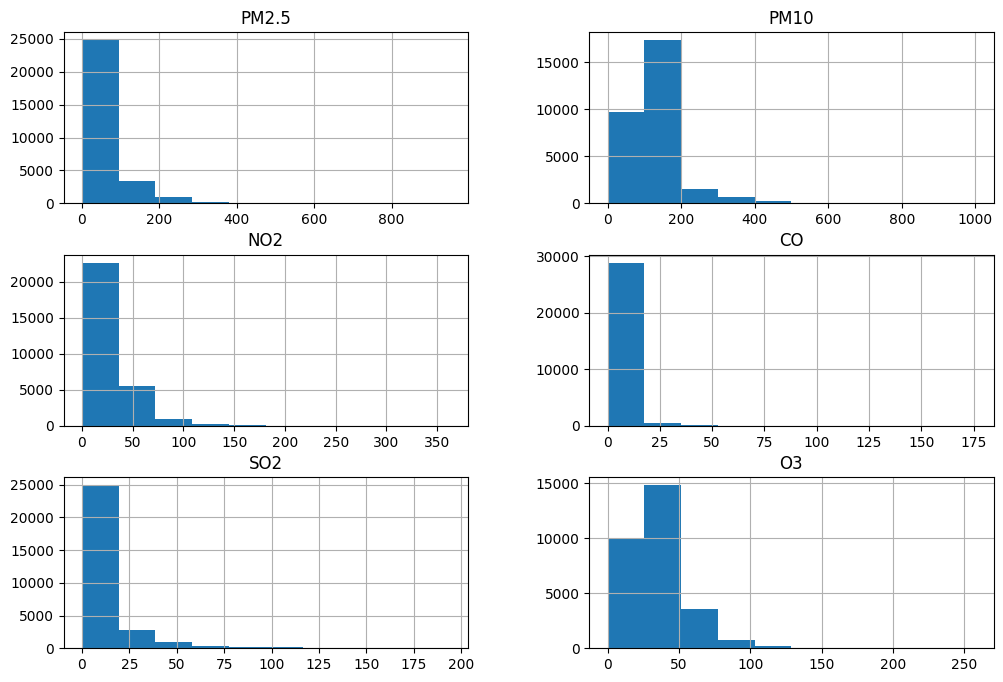

In [ ]:
#EDA
# Distribution of pollutants

df[['PM2.5','PM10','NO2','CO','SO2','O3']].hist(figsize=(12,8))
plt.show()

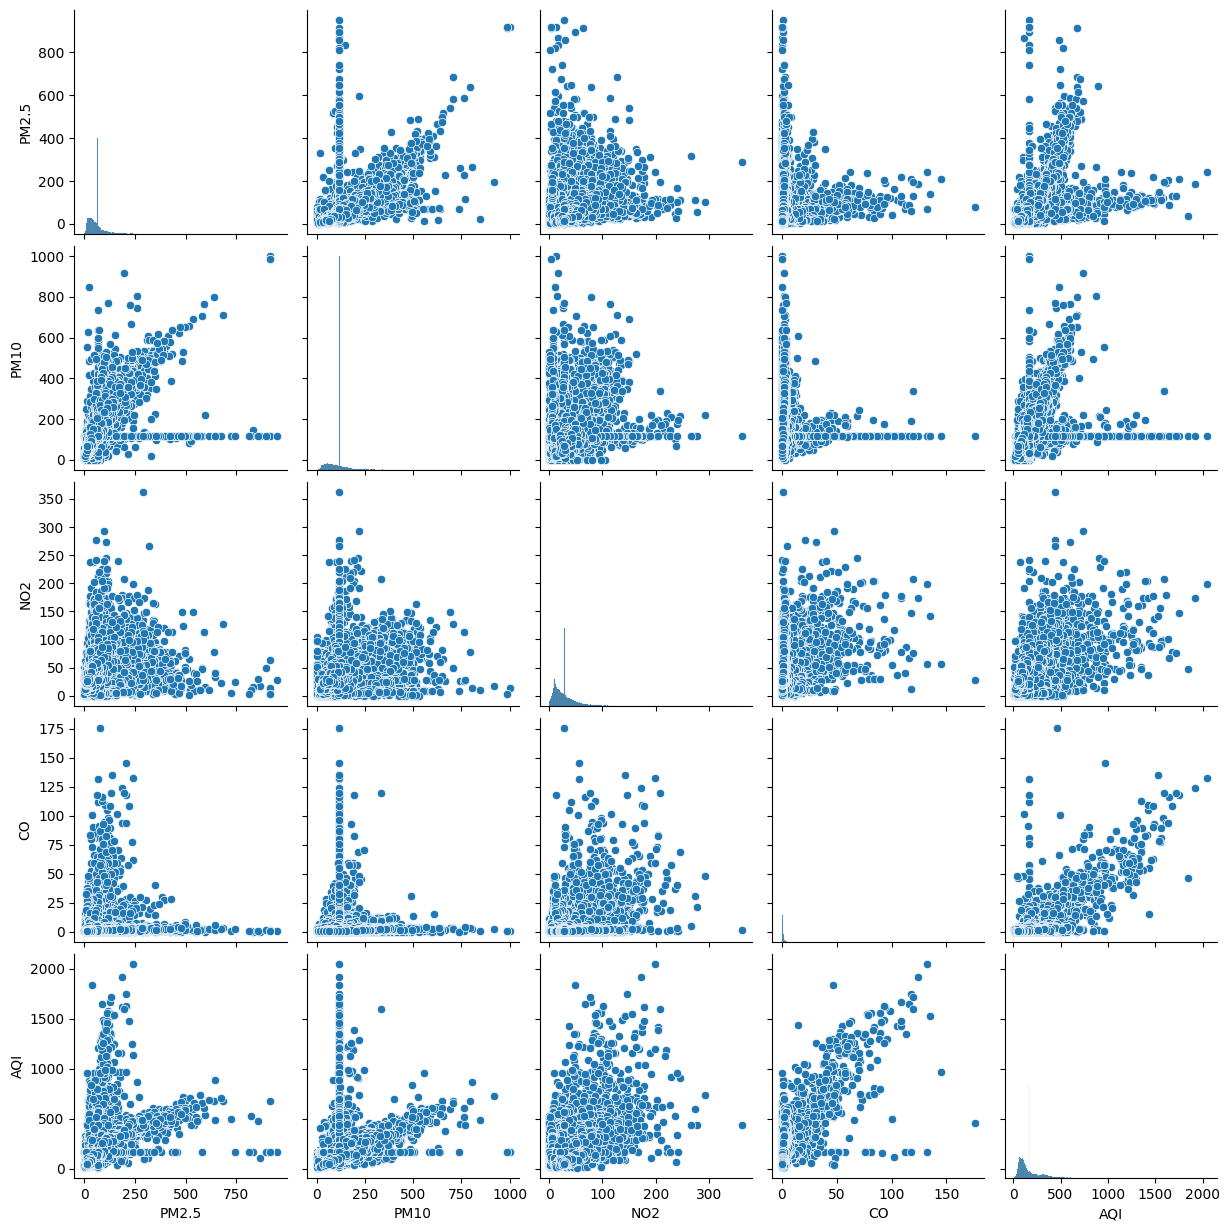

In [ ]:
df_selected = df[['PM2.5','PM10','NO2','CO','AQI']]
sns.pairplot(df_selected)
plt.show()

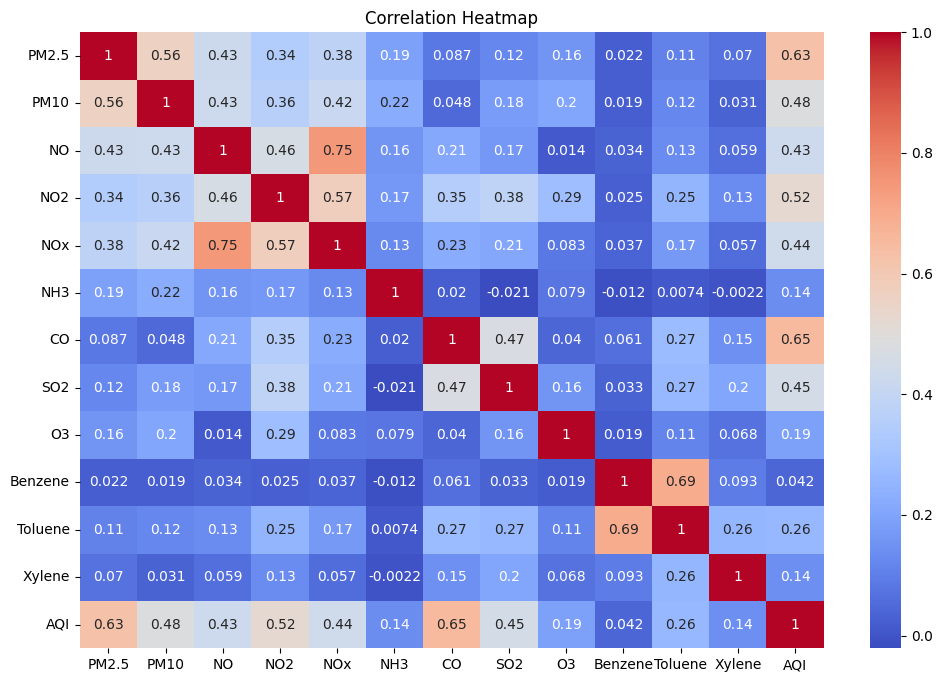

In [ ]:
# check which pollutants affect AQI
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
x = df[["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]]
y = df["AQI"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred[:10])

[143.40963188 143.40963188 134.10184579 179.00719808 292.78298447
  97.84761679 166.38485404 131.18460587 144.08342193 106.10421816]


In [ ]:
#model building
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(x_train_scaled,y_train)

KNeighborsRegressor()

In [ ]:
#Model evaluation
#Evaluation of Linear regression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred_lr=lr.predict(x_test_scaled)
print("Linear Regression")
print("prediction of linear regression",y_pred_lr)
lr_mse=mean_squared_error(y_test,y_pred_lr)
lr_mae=mean_absolute_error(y_test,y_pred_lr)
lr_R2=r2_score(y_test,y_pred_lr)
print("MSE:",lr_mse)
print("MAE:",lr_mae)
print("R2:", lr_R2)

Linear Regression
prediction of linear regression [143.40963188 143.40963188 134.10184579 ... 125.34189815  88.56116019
 142.30478205]
MSE: 2943.382240683026
MAE: 31.539159013566408
R2: 0.8047577753531739


In [ ]:
#Evaluation of Decision Tree
y_pred_dt = dt.predict(x_test)
print("Decision Tree")
print("prediction of decision tree:",y_pred_dt)
dt_mse=mean_squared_error(y_test,y_pred_dt)
dt_mae=mean_absolute_error(y_test,y_pred_dt)
dt_R2=r2_score(y_test,y_pred_dt)
print("MSE:",dt_mse)
print("MAE:",dt_mae)
print("R2:",dt_R2)

Decision Tree
prediction of decision tree: [166.46358149 166.46358149 139.         ... 121.          70.
 129.        ]
MSE: 3274.9929770697354
MAE: 28.07229146720557
R2: 0.7827611698854828


In [ ]:
#evaluation of Random forest
y_pred_rf = rf.predict(x_test)
print("Random Forest")
print("prediction of random forest:",y_pred_rf)
rf_mse=mean_squared_error(y_test,y_pred_rf)
rf_mae=mean_absolute_error(y_test,y_pred_rf)
rf_R2=r2_score(y_test,y_pred_rf)
print("MSE:",rf_mse)
print("MSE:",rf_mae)
print("R2:",rf_R2)

Random Forest
prediction of random forest: [166.46358149 166.46358149 138.1724507  ... 102.46927163  71.19
 155.31172233]
MSE: 1761.0227593381424
MSE: 20.459302022572782
R2: 0.8831867650641649


In [ ]:
#evaluation of knn
y_pred_knn=knn.predict(x_test_scaled)
print("KNN")
print("prediction of knn:",y_pred_knn)
knn_mse=mean_squared_error(y_test,y_pred_knn)
knn_mae=mean_absolute_error(y_test,y_pred_knn)
knn_R2=r2_score(y_test,y_pred_knn)
print("MSE:",knn_mse)
print("MAE:",knn_mae)
print("R2:",knn_R2)

KNN
prediction of knn: [166.46358149 166.46358149 131.4927163  ...  92.4         71.4
 132.8       ]
MSE: 2516.2378286090257
MAE: 23.62302186915296
R2: 0.8330913788199924


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
param_grid={
    'n_estimators':[100],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}
grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=3,scoring='r2',n_jobs=-1)
grid.fit(x_train,y_train)
print("Best parameters:",grid.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:

best_params = grid.best_params_
rf_tuned = RandomForestRegressor(random_state=42, **best_params)


rf_tuned.fit(x_train, y_train)


y_pred_rf_tuned = rf_tuned.predict(x_test)


rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_R2 = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance:")
print("prediction of tuned random forest",y_pred_rf_tuned)
print("MSE:", rf_tuned_mse)
print("MAE:", rf_tuned_mae)
print("R2:", rf_tuned_R2)

Tuned Random Forest Performance:
prediction of tuned random forest [164.47473194 164.47473194 124.29676621 ... 109.67661134  72.32458795
 159.82701649]
MSE: 1840.452876450124
MAE: 22.21519928607616
R2: 0.8779179581268428


               Model          MSE        MAE        R2
0  Linear Regression  2943.382241  31.539159  0.804758
1      Decision Tree  3274.992977  28.072291  0.782761
2      Random Forest  1761.022759  20.459302  0.883187
3                KNN  2516.237829  23.623022  0.833091


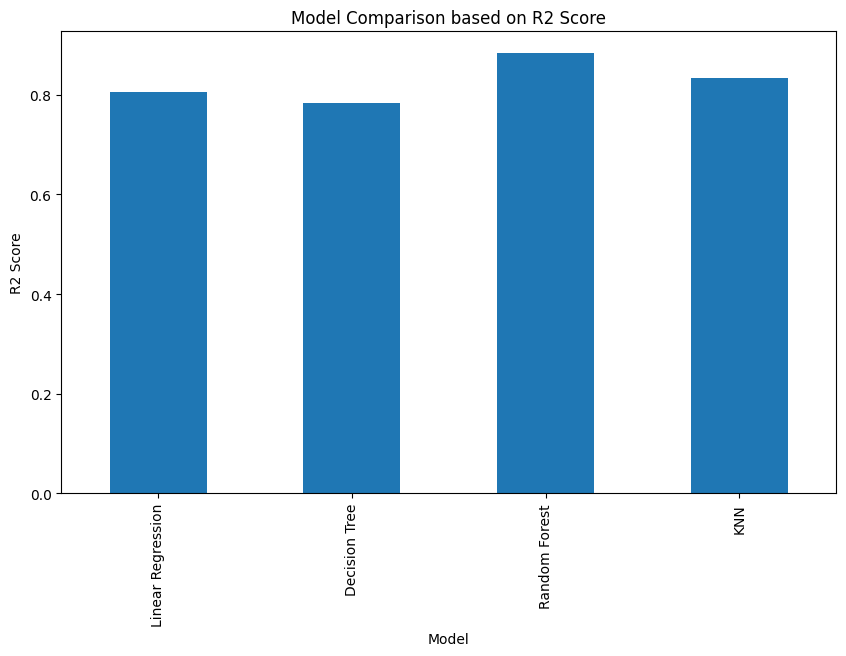

In [ ]:
# model comparisons before hyperparameter tuning
import pandas as pd
import matplotlib.pyplot as plt
results = pd.DataFrame({
    'Model':['Linear Regression','Decision Tree','Random Forest','KNN'],
    'MSE' :[lr_mse,dt_mse,rf_mse,knn_mse],
    'MAE' :[lr_mae,dt_mae,rf_mae,knn_mae],
    'R2' :[lr_R2,dt_R2,rf_R2,knn_R2]

})
print(results)
# Plot the R2 scores
results.set_index('Model')['R2'].plot(kind='bar', figsize=(10, 6))
plt.title("Model Comparison based on R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.show()

                   Model          MSE        MAE        R2
0      Linear Regression  2943.382241  31.539159  0.804758
1          Decision Tree  3274.992977  28.072291  0.782761
2                    KNN  2516.237829  23.623022  0.833091
3  Random Forest (Tuned)  1840.452876  22.215199  0.877918


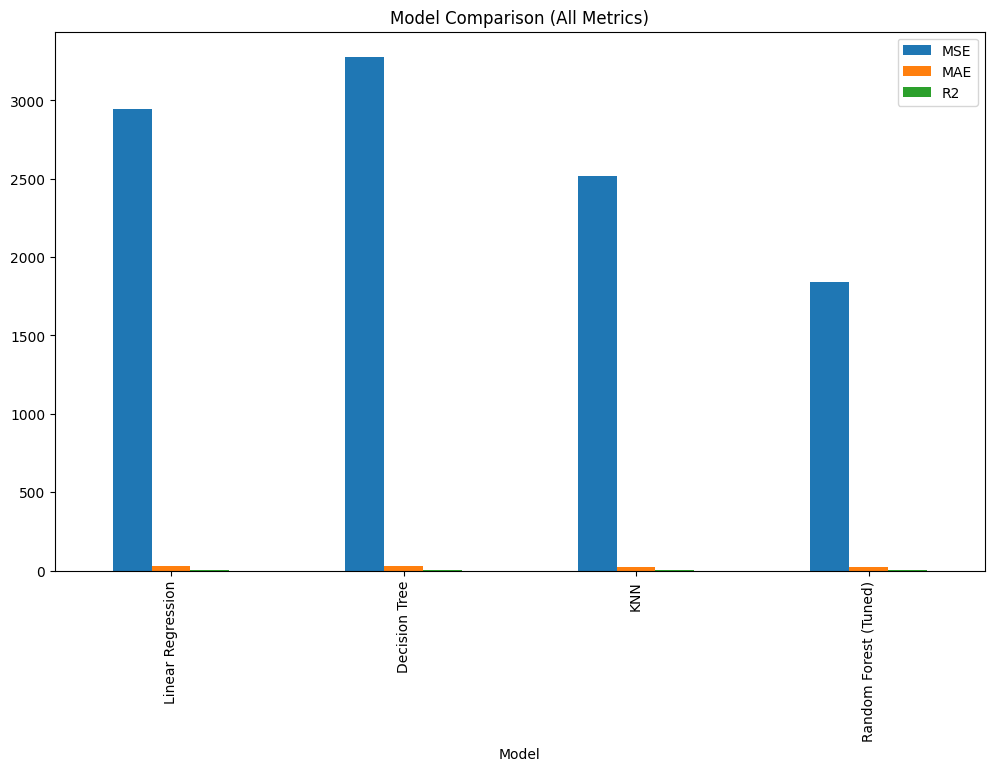

In [ ]:
#model comparison after tuning best model
results_updated = pd.DataFrame({
    'Model':['Linear Regression','Decision Tree','KNN', 'Random Forest (Tuned)'],
    'MSE' :[lr_mse,dt_mse,knn_mse, rf_tuned_mse],
    'MAE' :[lr_mae,dt_mae,knn_mae, rf_tuned_mae],
    'R2' :[lr_R2,dt_R2,knn_R2, rf_tuned_R2]
})

print(results_updated)

results_updated.set_index('Model')[['MSE','MAE','R2']].plot(kind='bar', figsize=(12,7))
plt.title("Model Comparison (All Metrics)")
plt.show()

In [ ]:
best_model= results_updated.loc[results_updated['R2'].idxmax()]
print("The best performing model :")
print(best_model)

The best performing model :
Model    Random Forest (Tuned)
MSE                1840.452876
MAE                  22.215199
R2                    0.877918
Name: 3, dtype: object


PM2.5 : 0.498699604203966
PM10 : 0.034800925952926796
NO : 0.03608495148862915
NO2 : 0.010800860616110538
NOx : 0.011905300581773007
NH3 : 0.0015053670852134158
CO : 0.3642660422920647
SO2 : 0.011880015047520846
O3 : 0.011856425065760016
Benzene : 0.004248894325925203
Toluene : 0.008604568506110383
Xylene : 0.005347044833999884


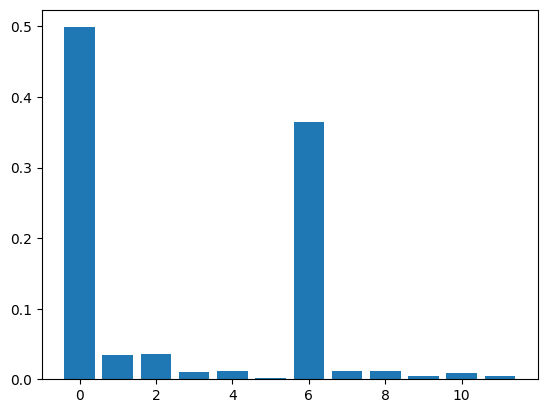

In [ ]:
#feature importance
importance = rf_tuned.feature_importances_

for i,v in enumerate(importance):
    print(x.columns[i],":",v)
plt.bar([x for x in range(len(importance))],importance)
plt.show()

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, x, y, cv=5)

array([0.63746966, 0.83280016, 0.69091751, 0.72110983, 0.76044974])

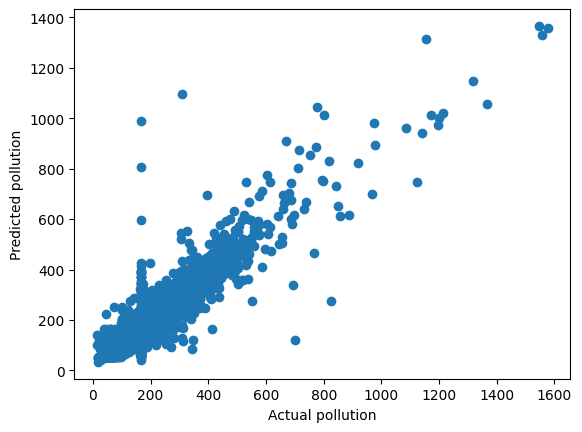

In [ ]:
#prediction
plt.scatter(y_test,y_pred_rf_tuned)
plt.xlabel("Actual pollution")
plt.ylabel("Predicted pollution")
plt.show()

In [ ]:
# Business Insights
#Top 10 highest AQI
print(df.sort_values(by='AQI', ascending=False).head(10))

           City       Date   PM2.5        PM10      NO     NO2     NOx  \
1145  Ahmedabad 2018-02-19  242.66  118.127103  132.47  199.17  246.03   
1136  Ahmedabad 2018-02-10  185.77  118.127103  124.01  172.84  186.66   
560   Ahmedabad 2016-07-14   38.13  118.127103   46.51   48.06   43.98   
1048  Ahmedabad 2017-11-14  207.19  118.127103  118.02  146.18  159.36   
1463  Ahmedabad 2019-01-03  131.50  118.127103  119.68   75.82   88.04   
1417  Ahmedabad 2018-11-18  127.46  118.127103  108.81   77.65  129.43   
1420  Ahmedabad 2018-11-21   86.52  118.127103  115.87   66.59   81.77   
1407  Ahmedabad 2018-11-08  205.21  118.127103   93.31  100.87   77.22   
1127  Ahmedabad 2018-02-01  189.12  118.127103   94.00  178.13  160.97   
1746  Ahmedabad 2019-10-13  194.36  335.860000  119.30  207.05  223.66   

            NH3      CO         SO2        O3  Benzene  Toluene  Xylene  \
1145  23.483476  132.47   14.531977  44.06000     0.74     5.81    3.21   
1136  23.483476  124.01  120.940000

In [ ]:
city_aqi=df.groupby("City")["AQI"].mean()
worst_air=city_aqi.idxmax()
print("City with high AQI:",worst_air)
better_air=city_aqi.idxmin()
print("City with low AQI:",better_air)
corr=df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)
print("\nTop factors affecting AQI")
print(corr[1:4])

City with high AQI: Ahmedabad
City with low AQI: Aizawl

Top factors affecting AQI
CO       0.649679
PM2.5    0.628860
NO2      0.522994
Name: AQI, dtype: float64


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Screenshot (652).png to Screenshot (652).png


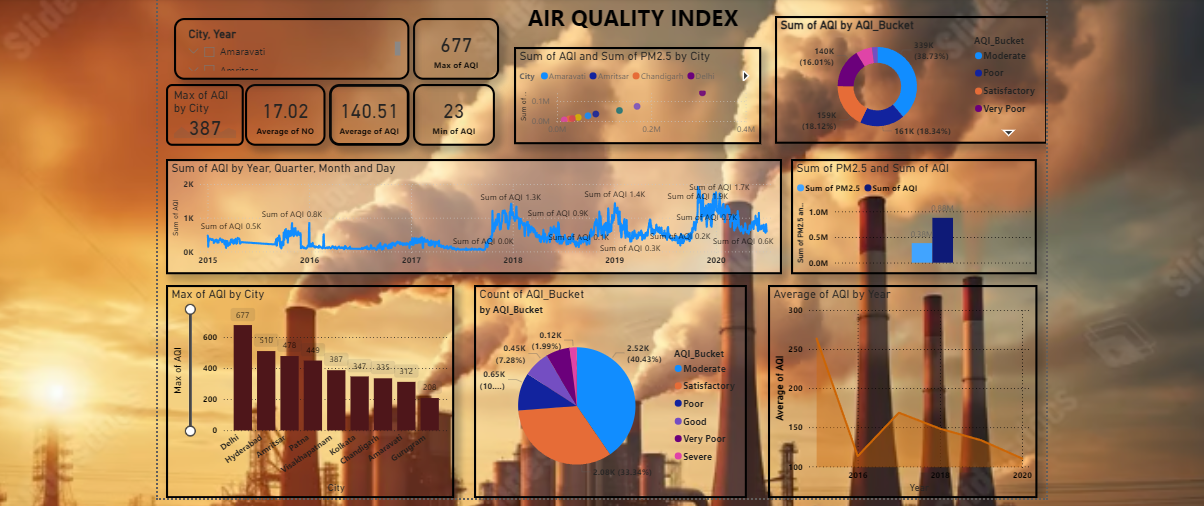

In [ ]:
from IPython.display import Image
Image('Screenshot (652).png')